comparamos los datos de produccion de limon con semilla de la zona de apatzingan Michoacan encontrados en la pagina https://nube.agricultura.gob.mx/avance_agricola/
 y los datos historicos de la conagua https://smn.conagua.gob.mx/tools/RESOURCES/Normales_Climatologicas/Mensuales/mich/mes16007.txt

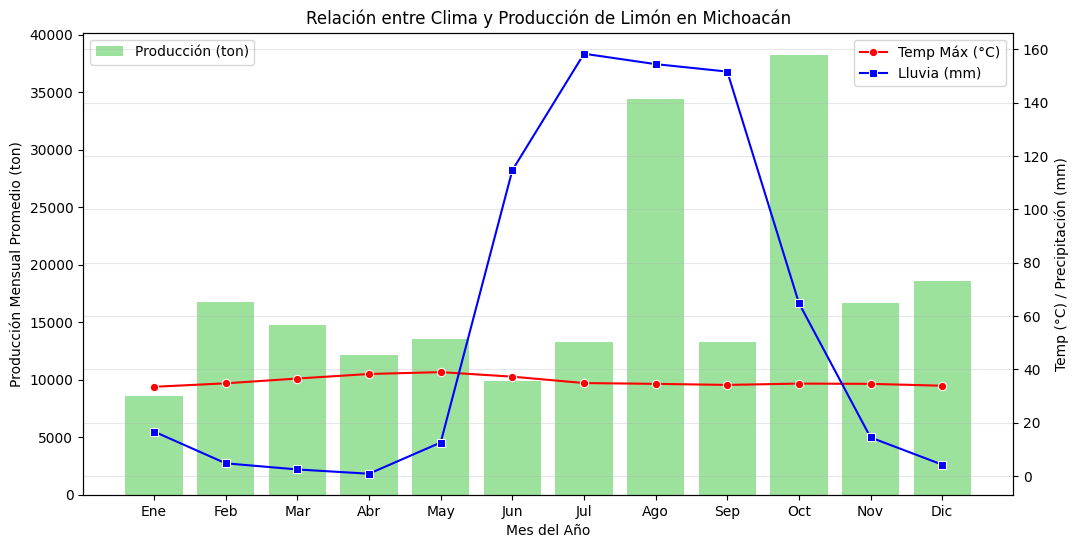

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos de producción (Sube tu archivo 'mes ames limon .csv' a Colab)
df_prod = pd.read_csv('mes ames limon .csv', encoding='latin1')

# Limpieza de nombres de columnas y conversión de tipos
df_prod['Producción'] = df_prod['Producci\u0097n'].str.replace(',', '').astype(float)

# Map Spanish month abbreviations to English
spanish_to_english_months = {
    'ene': 'Jan', 'feb': 'Feb', 'mar': 'Mar', 'abr': 'Apr', 'may': 'May', 'jun': 'Jun',
    'jul': 'Jul', 'ago': 'Aug', 'sep': 'Sep', 'oct': 'Oct', 'nov': 'Nov', 'dic': 'Dec'
}

def map_month_abbreviation(date_str):
    # Handle non-string values like NaN
    if pd.isna(date_str):
        return date_str

    s_date_str = str(date_str).lower()
    for sp_month, en_month in spanish_to_english_months.items():
        if s_date_str.startswith(sp_month):
            # Replace only the month abbreviation at the beginning of the string
            return s_date_str.replace(sp_month, en_month, 1)
    return date_str # Return original if no mapping found or not a valid month format

df_prod['Fecha'] = df_prod['Fecha'].apply(map_month_abbreviation)
df_prod['Fecha'] = pd.to_datetime(df_prod['Fecha'], format='%b-%y', errors='coerce')

# Calcular la producción mensual real (restando el acumulado del mes previo)
# Solo restamos si el mes anterior es del mismo año
df_prod['Prod_Mensual'] = df_prod.groupby(df_prod['Fecha'].dt.year)['Producción'].diff().fillna(df_prod['Producción'])

# 2. Datos Climatológicos (Promedios históricos Estación 16007 - Apatzingán)
clima_data = {
    'Mes_Num': range(1, 13),
    'Temp_Max': [33.5, 34.8, 36.6, 38.3, 39.0, 37.3, 34.9, 34.6, 34.2, 34.7, 34.6, 33.9],
    'Precipitacion': [16.7, 4.8, 2.5, 0.9, 12.6, 114.7, 158.4, 154.5, 151.7, 64.9, 14.5, 4.3]
}
df_clima = pd.DataFrame(clima_data)

# Promediar la producción por mes para ver la tendencia estacional
df_mensual_avg = df_prod.groupby(df_prod['Fecha'].dt.month)['Prod_Mensual'].mean().reset_index()
df_final = pd.merge(df_mensual_avg, df_clima, left_on='Fecha', right_on='Mes_Num')

# 3. Visualización
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfica de barras para Producción
sns.barplot(x='Mes_Num', y='Prod_Mensual', data=df_final, ax=ax1, color='lightgreen', label='Producción (ton)')
ax1.set_ylabel('Producción Mensual Promedio (ton)')
ax1.set_xlabel('Mes del Año')

# Eje secundario para Temperatura y Lluvia
ax2 = ax1.twinx()
sns.lineplot(x=range(0, 12), y='Temp_Max', data=df_final, ax=ax2, color='red', marker='o', label='Temp Máx (°C)')
sns.lineplot(x=range(0, 12), y='Precipitacion', data=df_final, ax=ax2, color='blue', marker='s', label='Lluvia (mm)')
ax2.set_ylabel('Temp (°C) / Precipitación (mm)')

plt.title('Relación entre Clima y Producción de Limón en Michoacán')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.xticks(range(0, 12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(alpha=0.3)
plt.show()

La relación entre la temperatura y la humedad en el cultivo del limón es un equilibrio biológico delicado. No se trata solo de "calor", sino de cómo ese calor interactúa con el agua disponible para la planta a través de la evapotranspiración.\\

Alta Temperatura + Alta Humedad = Cosecha Óptima
Cuando ambos factores son altos (dentro de los rangos tolerables del limón, aproximadamente entre 25°C y 34°C), se crea un "efecto invernadero" natural que acelera el metabolismo de la planta. En el caso de michoacan las temperaturas van de los 33° a los 39°C lo que genera un clima optimo para la produccion del limon durante todo el año.
La producción de limón en Michoacán presenta un incremento significativo durante los meses con mayor precipitación, particularmente entre julio y octubre. \
\La temperatura máxima muestra variaciones moderadas a lo largo del año, por lo que la precipitación parece ser el factor climático con mayor influencia sobre el rendimiento agrícola. Los mayores niveles de producción coinciden con la temporada de lluvias, sugiriendo una relación positiva entre disponibilidad hídrica y productividad del cultivo.

In [ ]:
modelo climatico/agronomico

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

# Variables independientes
X = df_final[['Temp_Max', 'Precipitacion']]

# Variable dependiente
y = df_final['Prod_Mensual']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Crear modelo
modelo = LinearRegression()

# Entrenar
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Evaluación
print("R²:", r2_score(y_test, y_pred))

# Coeficientes
print("Intercepto:", modelo.intercept_)

print("Coeficientes:")
for nombre, coef in zip(X.columns, modelo.coef_):
    print(nombre, coef)

R²: -0.11874175933739717
Intercepto: 72499.6477365369
Coeficientes:
Temp_Max -1578.731951367417
Precipitacion 8.279042301451504


si la temperatura maxima es negativa quiere decir que entre mayor calor menor producción, y si la precipitacion es positiva mientras mas precipitacion mayor sera la producción

In [ ]:
#modelo sarima

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


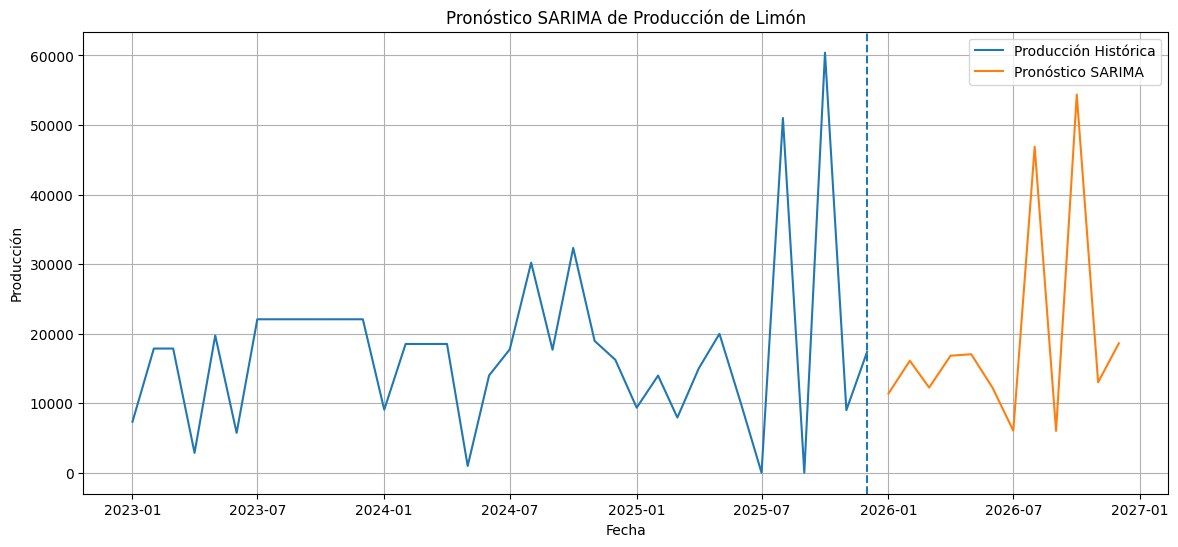

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Preparar serie

df_prod = df_prod.sort_index()

df_prod.index = pd.to_datetime(df_prod.index)

df_prod = df_prod.asfreq('MS')

serie = df_prod['Prod_Mensual'].dropna()

### Modelo SARIMA


modelo = SARIMAX(
    serie,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

resultado = modelo.fit()

# Pronóstico


n_periodos = 12

pred = resultado.forecast(steps=n_periodos)


# Fechas futuras


fechas_futuras = pd.date_range(
    start=serie.index[-1] + pd.DateOffset(months=1),
    periods=n_periodos,
    freq='MS'
)

pred = pd.Series(
    pred.values,
    index=fechas_futuras
)

# Histórico desde 2020


serie_2020 = serie[serie.index >= '2020-01-01']


# Gráfica


plt.figure(figsize=(14,6))

# Histórico
plt.plot(
    serie_2020,
    label='Producción Histórica'
)

# Pronóstico
plt.plot(
    pred,
    label='Pronóstico SARIMA'
)

# Línea divisoria
plt.axvline(
    x=serie.index[-1],
    linestyle='--'
)

plt.title('Pronóstico SARIMA de Producción de Limón')

plt.xlabel('Fecha')
plt.ylabel('Producción')

plt.legend()

plt.grid(True)

plt.show()

El modelo SARIMA se utiliza para analizar y pronosticar series temporales con comportamiento estacional, como la producción de limón, la cual depende de factores climáticos y ciclos agrícolas anuales. A diferencia de ARIMA, SARIMA incorpora la estacionalidad mensual, permitiendo identificar patrones repetitivos relacionados con las lluvias, temperatura y temporadas de cosecha.

SARIMA(p,d,q)(P,D,Q,s)

SARIMA(p,d,q)(P,D,Q,s)

En este caso, el modelo analiza la producción histórica de limón y genera un pronóstico futuro usando los patrones observados en los datos. Los resultados muestran que la producción aumenta principalmente durante o después de los meses con mayor precipitación, lo que sugiere una relación positiva entre lluvia y rendimiento agrícola.

El modelo tiene aplicaciones importantes en:

pronóstico de cosechas
planeación agrícola
estimación de oferta y precios
análisis del impacto climático
apoyo en logística y comercialización

SARIMA es especialmente útil para el cultivo de limón porque considera la naturaleza estacional de la producción agrícola y permite realizar estimaciones futuras más realistas que un modelo ARIMA tradicional.